# Invariant Generator Training Analysis

Use this notebook after a training run to inspect loss trends, test metrics, gradient flow, and the sparse invariant encoder `S`. Update the paths in the first code cell if you trained with a different config or `run_id`.

Loss terms: `data` fits predicted yield value to the target, `param` is MLP weight regularization, `structure` keeps trainable structure tensors normalized, and `encoder` regularizes the sparse encoder matrix `S`.

If plotting dependencies are missing, install them with `uv add --dev matplotlib notebook` from the project root.

In [33]:
from pathlib import Path
import os
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists() and (PROJECT_ROOT.parent / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

RUN_DIR = PROJECT_ROOT / "results" / "hill_exp01"
CONFIG_PATH = PROJECT_ROOT / "configs" / "default.toml"
CHECKPOINT_PATH = RUN_DIR / "checkpoint_best.pt"
HISTORY_PATH = RUN_DIR / "history.json"

sys.path.insert(0, str(PROJECT_ROOT / "src"))
MPLCONFIGDIR = PROJECT_ROOT / ".matplotlib-cache"
MPLCONFIGDIR.mkdir(exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPLCONFIGDIR))

print("project:", PROJECT_ROOT)
print("run dir:", RUN_DIR)
print("config:", CONFIG_PATH)
print("checkpoint:", CHECKPOINT_PATH)
print("history:", HISTORY_PATH)

project: /mimer/NOBACKUP/groups/naiss2026-4-599/projects/symbolic regression/Invariant-Generator
run dir: /mimer/NOBACKUP/groups/naiss2026-4-599/projects/symbolic regression/Invariant-Generator/results/hill_exp01
config: /mimer/NOBACKUP/groups/naiss2026-4-599/projects/symbolic regression/Invariant-Generator/configs/default.toml
checkpoint: /mimer/NOBACKUP/groups/naiss2026-4-599/projects/symbolic regression/Invariant-Generator/results/hill_exp01/checkpoint_best.pt
history: /mimer/NOBACKUP/groups/naiss2026-4-599/projects/symbolic regression/Invariant-Generator/results/hill_exp01/history.json


In [34]:
import json
from pprint import pprint

import numpy as np
import torch

try:
    ip = get_ipython()
    if ip is not None:
        ip.run_line_magic("matplotlib", "inline")
except NameError:
    pass

try:
    import matplotlib.pyplot as plt
except ImportError as exc:
    raise ImportError(
        "matplotlib is required for this notebook. Install it with: "
        "uv add --dev matplotlib notebook"
    ) from exc

from invariant_generator.config import load_config
from invariant_generator.data import prepare_training_data
from invariant_generator.evaluation import evaluate_model, predict_numpy
from invariant_generator.model import InvariantYieldModel

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True

In [35]:
with HISTORY_PATH.open("r", encoding="utf-8") as f:
    payload = json.load(f)

history = payload.get("history", [])
if not history:
    raise ValueError(f"No history rows found in {HISTORY_PATH}")

epochs = np.array([row["epoch"] for row in history], dtype=float)
# print("history rows:", len(history))
# print("first epoch:", history[0]["epoch"], "last epoch:", history[-1]["epoch"])
# print("top-level keys:")
# pprint(sorted(payload.keys()))
# print("history keys:")
# pprint(sorted(history[-1].keys()))

In [36]:
parameter_counts = payload.get("parameter_counts")
if parameter_counts is None:
    print("No parameter_counts in history.json; load the checkpoint/model below for counts.")
else:
    pprint(parameter_counts)

{'encoder_total': 100,
 'encoder_trainable': 100,
 'invariant_pool_total': 9,
 'invariant_pool_trainable': 9,
 'regressor_total': 4929,
 'regressor_trainable': 4929,
 'total': 5038,
 'trainable': 5038}


In [37]:
def series(name, default=np.nan):
    return np.array([row.get(name, default) for row in history], dtype=float)

def available(name):
    return any(name in row for row in history)

def positive_for_log(values):
    values = np.asarray(values, dtype=float)
    return np.isfinite(values).all() and np.nanmin(values) > 0.0

def plot_lines(ax, specs, title, ylabel="loss"):
    plotted = False
    for key, label in specs:
        if available(key):
            values = series(key)
            ax.plot(epochs, values, marker="o", linewidth=1.6, label=label)
            plotted = True
    ax.set_title(title)
    ax.set_xlabel("epoch")
    ax.set_ylabel(ylabel)
    if plotted:
        ax.legend()
        all_values = np.concatenate([series(key) for key, _ in specs if available(key)])
        if positive_for_log(all_values):
            ax.set_yscale("log")
    else:
        ax.text(0.5, 0.5, "not available", ha="center", va="center", transform=ax.transAxes)

LOSS_TERMS = [
    ("total", "total"),
    ("data", "data fit"),
    ("param", "MLP param reg"),
    ("structure", "structure reg"),
    ("encoder", "encoder reg"),
]

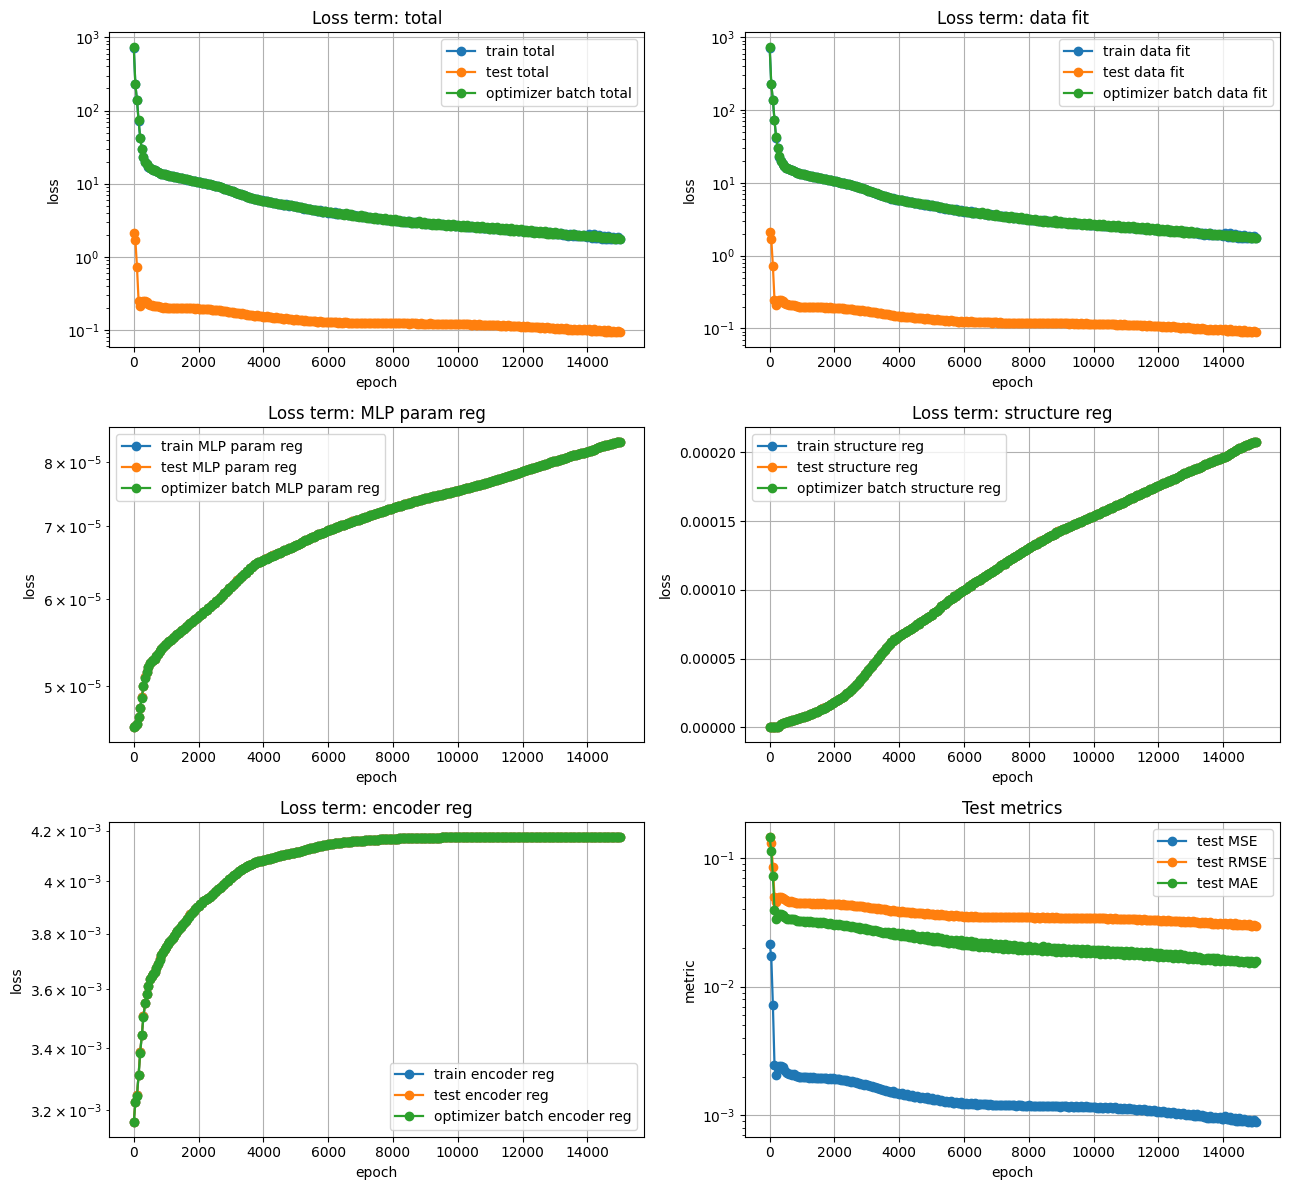

In [38]:
fig, axes = plt.subplots(3, 2, figsize=(13, 12))

for ax, (suffix, label) in zip(axes.flat[:5], LOSS_TERMS):
    plot_lines(
        ax,
        [
            (f"train_loss_{suffix}", f"train {label}"),
            (f"test_loss_{suffix}", f"test {label}"),
            (f"loss_{suffix}", f"optimizer batch {label}"),
        ],
        f"Loss term: {label}",
    )

plot_lines(
    axes.flat[5],
    [("test_mse", "test MSE"), ("test_rmse", "test RMSE"), ("test_mae", "test MAE")],
    "Test metrics",
    ylabel="metric",
)

fig.tight_layout()
plt.show()

In [39]:
def summarize_change(key):
    if not available(key):
        return None
    values = series(key)
    first = values[0]
    last = values[-1]
    change = last - first
    rel = change / first if np.isfinite(first) and first != 0.0 else np.nan
    return {"first": first, "last": last, "delta": change, "relative_delta": rel}

def print_loss_change_table(prefix):
    rows = []
    for suffix, label in LOSS_TERMS:
        key = f"{prefix}_loss_{suffix}"
        summary = summarize_change(key)
        if summary is None:
            continue
        rows.append((label, summary["first"], summary["last"], summary["delta"], summary["relative_delta"]))
    if not rows:
        print(f"No {prefix} loss-term history found.")
        return
    print(f"{prefix.upper()} loss-term changes")
    print(f"{'term':<16} {'first':>14} {'last':>14} {'delta':>14} {'rel_delta':>12}")
    for label, first, last, delta, rel in rows:
        print(f"{label:<16} {first:14.6g} {last:14.6g} {delta:14.6g} {rel:12.3%}")
    print()

print_loss_change_table("train")
print_loss_change_table("test")

for key in ["test_mse", "test_rmse", "test_mae"]:
    summary = summarize_change(key)
    if summary is not None:
        print(key)
        pprint(summary)

if available("grad_norm_encoder"):
    print("encoder grad norm min/max:", float(np.nanmin(series("grad_norm_encoder"))), float(np.nanmax(series("grad_norm_encoder"))))

TRAIN loss-term changes
term                      first           last          delta    rel_delta
total                   725.974        1.73617       -724.238     -99.761%
data fit                725.971         1.7317       -724.239     -99.761%
MLP param reg       4.58315e-05    8.35385e-05     3.7707e-05      82.273%
structure reg        1.9984e-12    0.000207756    0.000207756 10396119031.022%
encoder reg          0.00316376     0.00417555     0.00101178      31.980%

TEST loss-term changes
term                      first           last          delta    rel_delta
total                   2.14445      0.0925435       -2.05191     -95.685%
data fit                2.14125      0.0880767       -2.05317     -95.887%
MLP param reg       4.58315e-05    8.35385e-05     3.7707e-05      82.273%
structure reg        1.9984e-12    0.000207756    0.000207756 10396119031.022%
encoder reg          0.00316376     0.00417555     0.00101178      31.980%

test_mse
{'delta': np.float64(-0.0205316850

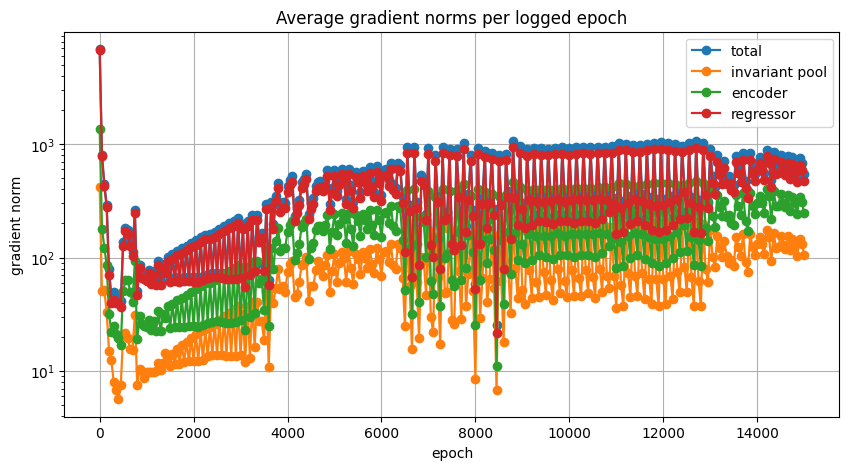

In [40]:
grad_specs = [
    ("grad_norm_total", "total"),
    ("grad_norm_invariant_pool", "invariant pool"),
    ("grad_norm_encoder", "encoder"),
    ("grad_norm_regressor", "regressor"),
]
fig, ax = plt.subplots(figsize=(10, 5))
plot_lines(ax, grad_specs, "Average gradient norms per logged epoch", ylabel="gradient norm")
plt.show()

In [41]:
config = load_config(CONFIG_PATH)
device = torch.device("cpu")
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)

model = InvariantYieldModel.from_config(config).to(device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("checkpoint epoch:", checkpoint.get("epoch"))
print("checkpoint metrics:")
pprint(checkpoint.get("metrics", {}))
print("model parameter counts:")
pprint(model.parameter_counts())

checkpoint epoch: 15000
checkpoint metrics:
{'mae': 0.015678595304489135,
 'max_abs_error': 0.19360268115997314,
 'mse': 0.0008807669871113432,
 'rmse': 0.029677718697894272,
 'sse': 0.08807669871113433}
model parameter counts:
{'encoder_total': 100,
 'encoder_trainable': 100,
 'invariant_pool_total': 9,
 'invariant_pool_trainable': 9,
 'regressor_total': 4929,
 'regressor_trainable': 4929,
 'total': 5038,
 'trainable': 5038}


S shape: (10, 10)
columns close to zero threshold: 0.001
    I2  col_l1=1.46382  col_l2=1.07748 
    I7  col_l1=1.51096  col_l2=1.11269 
    I3  col_l1=1.54296  col_l2=1.03146 
    I6  col_l1=1.59559  col_l2=1.17593 
    I5  col_l1=1.67058  col_l2=1.09813 
    I1  col_l1=1.67208  col_l2=1.17698 
    I9  col_l1=1.73628  col_l2=1.13516 
    I4  col_l1=1.77802  col_l2=1.23352 
   I10  col_l1=1.92747  col_l2=1.18026 
    I8  col_l1=2.31708  col_l2=1.44751 


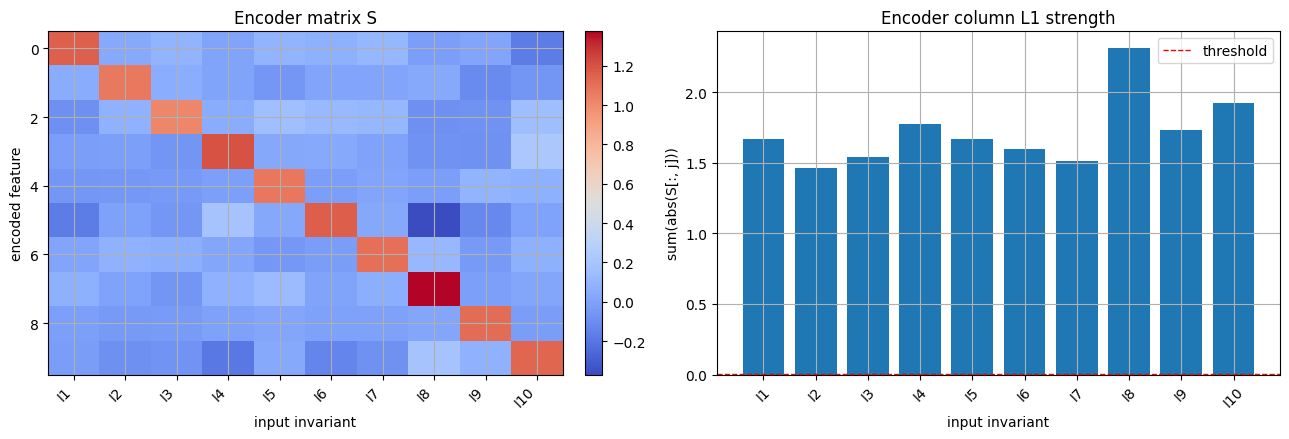

In [42]:
S = model.encoder_matrix()
invariant_names = list(config.invariants.selected)
ENCODER_ZERO_THRESHOLD = 1e-3

if S is None:
    print("Encoder is disabled for this run.")
else:
    S_np = S.detach().cpu().numpy()
    abs_S = np.abs(S_np)
    col_l1 = abs_S.sum(axis=0)
    col_l2 = np.sqrt((S_np ** 2).sum(axis=0))
    order = np.argsort(col_l1)

    print("S shape:", S_np.shape)
    print("columns close to zero threshold:", ENCODER_ZERO_THRESHOLD)
    for idx in order:
        flag = "LOW" if col_l1[idx] <= ENCODER_ZERO_THRESHOLD else ""
        print(f"{invariant_names[idx]:>6s}  col_l1={col_l1[idx]:.6g}  col_l2={col_l2[idx]:.6g} {flag}")

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    image = axes[0].imshow(S_np, aspect="auto", cmap="coolwarm")
    axes[0].set_title("Encoder matrix S")
    axes[0].set_xlabel("input invariant")
    axes[0].set_ylabel("encoded feature")
    axes[0].set_xticks(np.arange(len(invariant_names)))
    axes[0].set_xticklabels(invariant_names, rotation=45, ha="right")
    fig.colorbar(image, ax=axes[0], fraction=0.046, pad=0.04)

    axes[1].bar(invariant_names, col_l1)
    axes[1].axhline(ENCODER_ZERO_THRESHOLD, color="red", linestyle="--", linewidth=1, label="threshold")
    axes[1].set_title("Encoder column L1 strength")
    axes[1].set_xlabel("input invariant")
    axes[1].set_ylabel("sum(abs(S[:, j]))")
    axes[1].tick_params(axis="x", rotation=45)
    axes[1].legend()
    fig.tight_layout()
    plt.show()

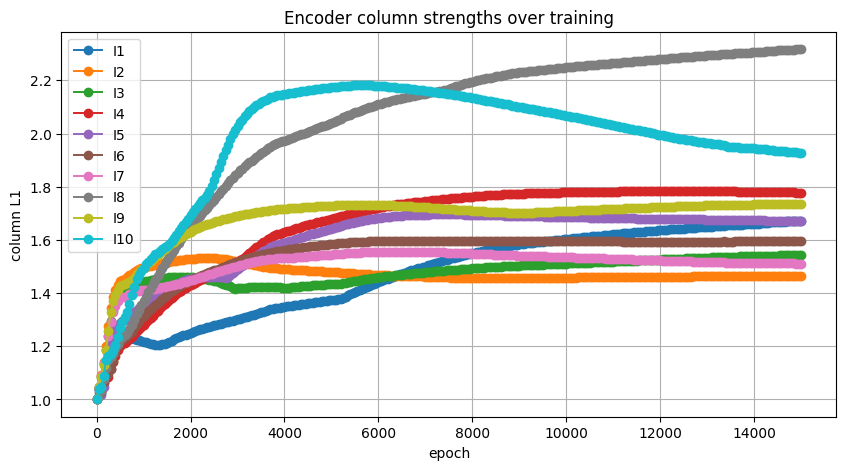

In [43]:
if S is not None:
    col_keys = [f"encoder_col_l1_{name}" for name in invariant_names]
    if any(available(key) for key in col_keys):
        fig, ax = plt.subplots(figsize=(10, 5))
        for name, key in zip(invariant_names, col_keys):
            if available(key):
                ax.plot(epochs, series(key), marker="o", linewidth=1.4, label=name)
        ax.set_title("Encoder column strengths over training")
        ax.set_xlabel("epoch")
        ax.set_ylabel("column L1")
        ax.legend()
        plt.show()
    else:
        print("Encoder column history is not available. Re-run training with the updated logger.")

In [30]:
try:
    data = prepare_training_data(config)
    print("train:", data.X_train.shape, "test:", data.X_test.shape)
except Exception as exc:
    data = None
    print("Could not load prepared data. Prediction/invariant diagnostics are skipped.")
    print(type(exc).__name__, exc)

train: (5400, 6) test: (100, 6)


raw invariant feature summary
      I1  mean= 2.6818e+00  std= 1.6625e+00  min= 1.6484e-01  max= 1.7660e+01
      I2  mean= 3.7354e+00  std= 1.2110e+00  min= 1.3774e+00  max= 1.1405e+01
      I3  mean= 3.3592e+00  std= 1.1583e+00  min= 9.5554e-01  max= 1.0206e+01
      I4  mean= 1.2637e+00  std= 1.0521e+00  min=-2.2267e+00  max= 4.9163e+00
      I5  mean= 1.7026e+00  std= 9.6390e-01  min=-4.5805e-01  max= 9.1418e+00
      I6  mean= 1.5637e+00  std= 1.1284e+00  min=-3.3690e+00  max= 5.9581e+00
      I7  mean= 2.7642e+00  std= 9.2071e-01  min= 8.8384e-01  max= 8.3950e+00
      I8  mean=-4.9091e-01  std= 4.5950e-01  min=-4.8482e+00  max= 4.7480e-01
      I9  mean=-1.7329e+00  std= 5.9964e-01  min=-5.9210e+00  max=-4.5236e-01
     I10  mean=-7.7481e-02  std= 7.9546e-01  min=-1.6054e+00  max= 1.7634e+00


/local/tmp.6734877/ipykernel_141669/1196945102.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([invariant_values[:, i] for i in range(invariant_values.shape[1])], labels=invariant_names)


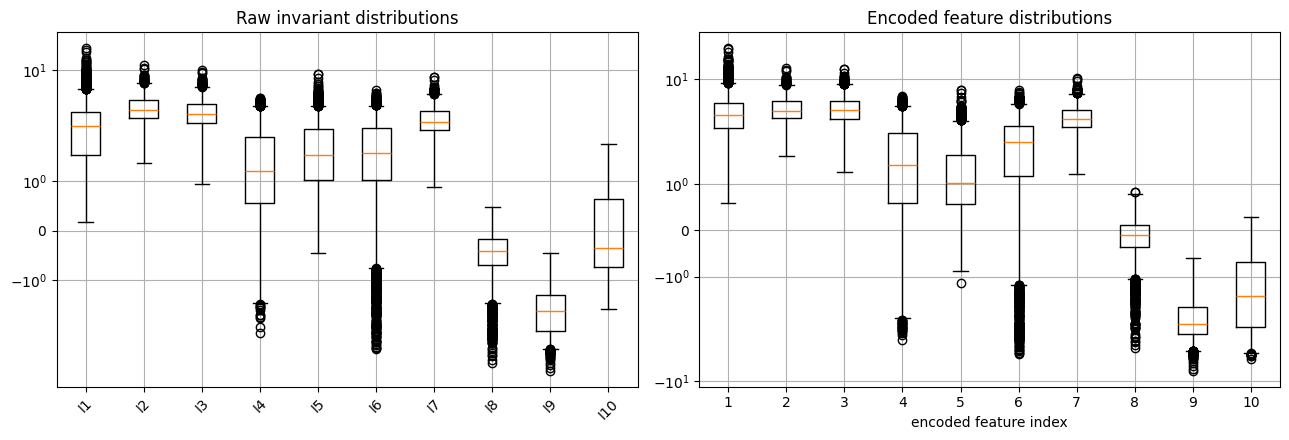

In [44]:
def print_feature_summary(names, values):
    values = np.asarray(values, dtype=float)
    for idx, name in enumerate(names):
        column = values[:, idx]
        print(
            f"{name:>8s}  mean={column.mean(): .4e}  std={column.std(): .4e}  "
            f"min={column.min(): .4e}  max={column.max(): .4e}"
        )

if data is not None:
    with torch.no_grad():
        X_sample = torch.as_tensor(data.X_train[: min(5000, len(data.X_train))], dtype=torch.float32)
        invariant_values = model.invariant_pool(X_sample).cpu().numpy()
        encoded_values = model.invariant_features(X_sample).cpu().numpy()

    print("raw invariant feature summary")
    print_feature_summary(invariant_names, invariant_values)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    axes[0].boxplot([invariant_values[:, i] for i in range(invariant_values.shape[1])], labels=invariant_names)
    axes[0].set_title("Raw invariant distributions")
    axes[0].tick_params(axis="x", rotation=45)
    axes[0].set_yscale("symlog")

    axes[1].boxplot([encoded_values[:, i] for i in range(encoded_values.shape[1])])
    axes[1].set_title("Encoded feature distributions")
    axes[1].set_xlabel("encoded feature index")
    axes[1].set_yscale("symlog")
    fig.tight_layout()
    plt.show()

{'mae': 0.015678595900535584,
 'max_abs_error': 0.1936028003692627,
 'mse': 0.000880768810731034,
 'rmse': 0.02967774942159587,
 'sse': 0.08807688107310341}


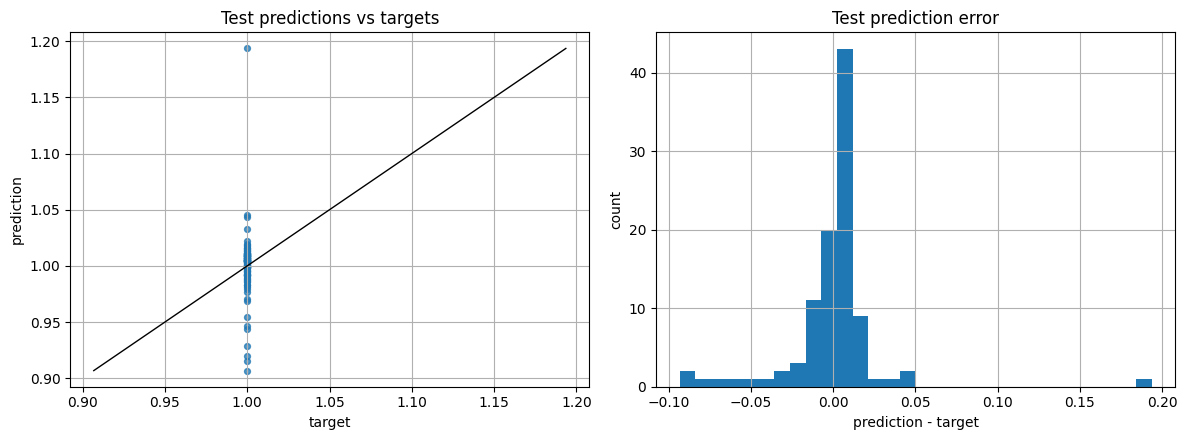

In [45]:
if data is not None:
    metrics = evaluate_model(model, data.X_test, data.y_test, device=device, batch_size=8192)
    pprint(metrics)
    y_pred = predict_numpy(model, data.X_test, device=device, batch_size=8192)
    y_true = data.y_test
    error = y_pred - y_true

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    axes[0].scatter(y_true, y_pred, s=18, alpha=0.75)
    low = min(float(y_true.min()), float(y_pred.min()))
    high = max(float(y_true.max()), float(y_pred.max()))
    axes[0].plot([low, high], [low, high], color="black", linewidth=1)
    axes[0].set_title("Test predictions vs targets")
    axes[0].set_xlabel("target")
    axes[0].set_ylabel("prediction")

    axes[1].hist(error, bins=30)
    axes[1].set_title("Test prediction error")
    axes[1].set_xlabel("prediction - target")
    axes[1].set_ylabel("count")
    fig.tight_layout()
    plt.show()